<a href="https://colab.research.google.com/github/IncharaPraveen/SeizureDetection/blob/main/seizure_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level('WARNING')

In [5]:

file_path = "/chb01_03.edf"

# Load the raw EEG data into memory.
# preload=True is required so we can apply filters to the data in memory.
raw = mne.io.read_raw_edf(file_path, preload=True)

# Drop non-EEG channels if they exist
raw.pick_types(eeg=True, exclude='bads')

print(f"Data loaded: {raw.info['nchan']} channels, sampled at {raw.info['sfreq']} Hz.")

/tmp/ipykernel_1657/3224942856.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Data loaded: 23 channels, sampled at 256.0 Hz.


In [6]:
# 1. Notch Filter: Remove the 60 Hz electrical hum from the Boston hospital power lines
raw.notch_filter(freqs=60.0)

# 2. Bandpass Filter: Restrict the signal to typical brainwave frequencies (0.5 to 50 Hz)
# - Below 0.5 Hz is usually slow sweat/movement drift
# - Above 50 Hz is usually muscle tension (EMG) or static
raw.filter(l_freq=0.5, h_freq=50.0)

print("60 Hz Notch and 0.5-50 Hz Bandpass filters applied successfully.")

60 Hz Notch and 0.5-50 Hz Bandpass filters applied successfully.


In [7]:
# Slice the continuous signal into 4-second windows with no overlap
window_size = 4.0
epochs = mne.make_fixed_length_epochs(raw, duration=window_size, overlap=0.0)

# Extract the raw voltage numbers into a Numpy array
# Shape will be: (Total_Windows, Number_of_Channels, Time_Samples_Per_Window)
X_raw = epochs.get_data()

# The summary text file stated the seizure occurred from 2996 to 3036 seconds.
seizure_start = 2996
seizure_end = 3036

#we get the freq 256Hz, each epoch is 4 seconds, 256 * 4 num of data points

# MNE stores the starting sample number for each window in epochs.events
sample_rate = raw.info['sfreq']
labels = []
#each epochs.events is a single epoch's start time and end time ( slices of epoch tracked)
for event in epochs.events:
    # Convert the sample number back to seconds
    onset_sec = event[0] / sample_rate
    #get start timing of this epoch in epochs.event[0]
    # Check if this 4-second window falls inside the seizure timeframe
    if seizure_start <= onset_sec < seizure_end:
        labels.append(1)  # Seizure window
    else:
        labels.append(0)  # Normal window

y = np.array(labels)
# array of labels created -> classifies each epoch as seizure or not

print(f"Matrix X shape: {X_raw.shape}")
print(f"Target y shape: {y.shape}")
print(f"Total Seizure Windows (Class 1): {np.sum(y)}")
print(f"Total Normal Windows (Class 0): {len(y) - np.sum(y)}")

Matrix X shape: (900, 23, 1024)
Target y shape: (900,)
Total Seizure Windows (Class 1): 10
Total Normal Windows (Class 0): 890


In [8]:
# Check the sampling rate (Hz)
sample_rate = raw.info['sfreq']
print(f"Sampling Rate: {sample_rate} Hz")

# List all the 23 electrode channels on the scalp (e.g., 'FP1-F7', 'T7-P7')
print(f"Channels: {raw.ch_names}")

# Check the exact dimensions of your machine learning matrix
print(f"Raw Matrix Shape: {X_raw.shape}") # e.g., (900, 23, 1024)

Sampling Rate: 256.0 Hz
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Raw Matrix Shape: (900, 23, 1024)


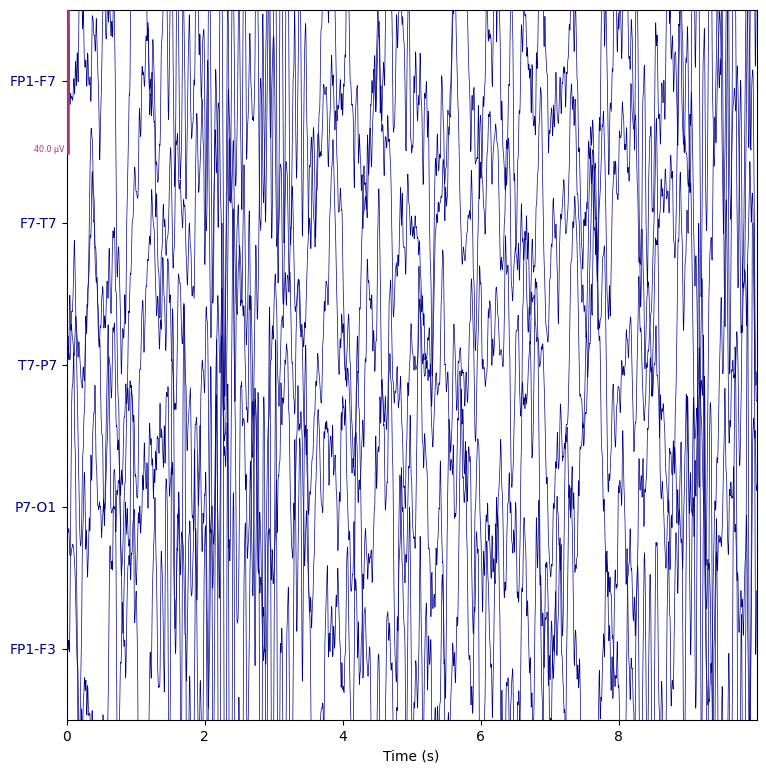

In [9]:
# Ensure plots render directly in the notebook
%matplotlib inline

# Plot 10 seconds of the filtered continuous brainwaves for the first 5 electrodes
fig_time = raw.plot(duration=10.0, n_channels=5, color='darkblue',
                    title="Filtered EEG (0.5 - 50 Hz)", show_scrollbars=False)

# Optional: Save the high-res image to your folder for the video
fig_time.savefig("eeg_time_domain.png", dpi=300)

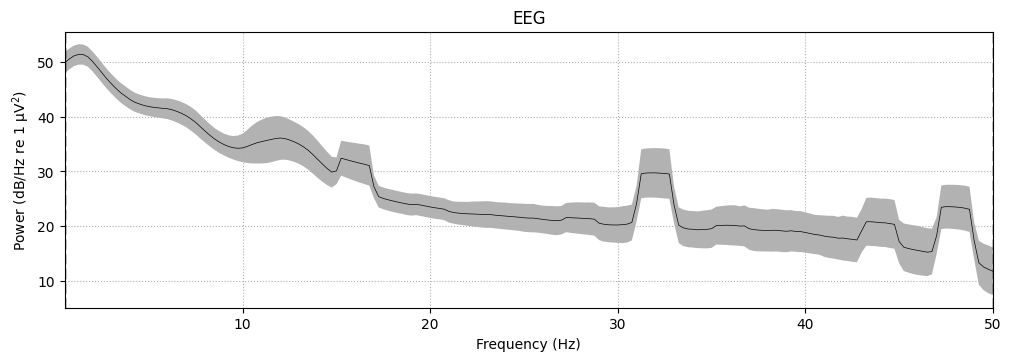

In [10]:
# Compute and plot the Power Spectral Density (PSD) up to 50 Hz
# This shows the actual frequency breakdown of your epochs
psd_fig = epochs.compute_psd(fmin=0.5, fmax=50.0).plot(average=True, spatial_colors=True)

# The resulting graph shows Frequency (Hz) on the X-axis and Power on the Y-axis.
psd_fig.savefig("eeg_frequency_spectrum.png", dpi=300)